In [3]:
# Open the dataset gesla_2004_selected_lowess_dac_correctedaustralia_2004.nc and explore the content

import xarray as xr
import matplotlib.pyplot as plt

file_path = 'gesla_2004_selected_lowess_dac_correctedaustralia_2004.nc'
dataset = xr.open_dataset(file_path)


# Print the dataset info
print(dataset)

# List all variables in the dataset
print(dataset.data_vars)

# Display the dimensions and coordinates
print(dataset.dims)
print(dataset.coords)


<xarray.Dataset>
Dimensions:                  (date_time: 8778, station: 80)
Coordinates:
  * station                  (station) int64 1452 1531 1503 ... 1469 1496 1497
  * date_time                (date_time) datetime64[ns] 2004-01-01T01:00:00 ....
Data variables: (12/31)
    sea_level                (station, date_time) float64 ...
    qc_flag                  (station, date_time) float64 ...
    use_flag                 (station, date_time) float64 ...
    filename                 (station) object ...
    site_name                (station) object ...
    site_code                (station) object ...
    ...                       ...
    gauge_type               (station) object ...
    overall_record_quality   (station) object ...
    sea_level_lowess         (station, date_time) float64 ...
    dac                      (station, date_time) float64 ...
    sla_dac                  (station, date_time) float64 ...
    sla_dac_no_loess         (station, date_time) float64 ...
Attribut

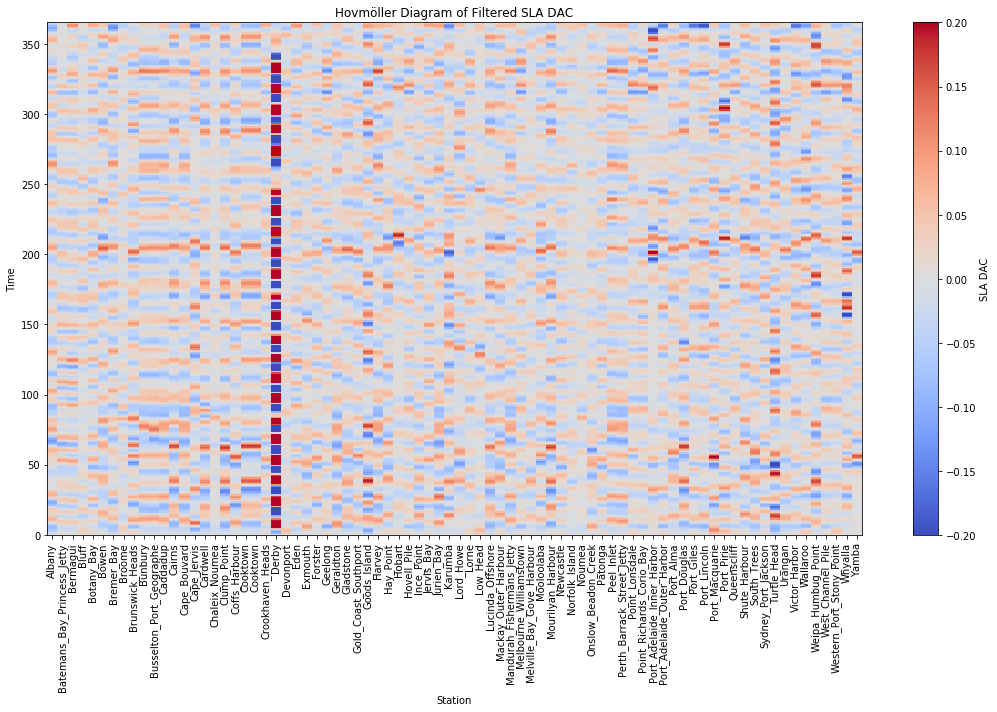

In [102]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
from scipy.signal import butter, filtfilt

# Load the dataset
file_path = 'gesla_2004_selected_lowess_dac_correctedaustralia_2004.nc'
dataset = xr.open_dataset(file_path)

# Convert hourly data to daily means
daily_dataset = dataset.resample(date_time='D').mean()

# Extract necessary variables
sla_dac = daily_dataset['sla_dac'].values
time = daily_dataset['date_time'].values
site_names = dataset['site_name'].values  # Keeping original site names, as they don't change with resampling

# Define the Butterworth bandpass filter
def butter_bandpass(lowcut, highcut, fs, order=5):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return b, a

def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = filtfilt(b, a, data, axis=0)
    return y

def interpolate_nan(data):
    """Interpolate NaNs in the data."""
    nans, x = np.isnan(data), lambda z: z.nonzero()[0]
    data[nans] = np.interp(x(nans), x(~nans), data[~nans])
    return data

# Frequency cutoffs in cycles per day
lowcut = 0.035
highcut = 0.15
fs = 1.0  # Sampling frequency in cycles per day

# Apply the Butterworth bandpass filter to each time series
filtered_sla_dac = []
valid_site_names = []
for i in range(sla_dac.shape[1]):
    series = sla_dac[:, i]
    nan_count = np.isnan(series).sum()
    if nan_count <= 0.9 * len(time):  # Keep if less than or equal to 90% NaNs
        if nan_count > 0:
            series = interpolate_nan(series)
        series = butter_bandpass_filter(series, lowcut, highcut, fs, order=5)
        filtered_sla_dac.append(series)
        valid_site_names.append(site_names[i])

filtered_sla_dac = np.array(filtered_sla_dac)

# Create the Hovmöller diagram using imshow with masked array
fig, ax = plt.subplots(figsize=(15, 10))

# Set normalization for the color scale
norm = Normalize(vmin=-0.2, vmax=0.2)

# Plot using imshow with masked array
im = ax.imshow(filtered_sla_dac.T, aspect='auto', cmap='coolwarm', origin='lower', norm=norm)

# Set labels and title
ax.set_xlabel('Station')
ax.set_ylabel('Time')
ax.set_title('Hovmöller Diagram of Filtered SLA DAC')

# Add colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('SLA DAC')

# Set x-axis ticks and labels
ax.set_xticks(np.arange(len(valid_site_names)))
ax.set_xticklabels(valid_site_names, rotation=90)

plt.tight_layout()
plt.show()


/home/passaro/anaconda3/envs/machine_learning_altimetry_validation/lib/python3.6/site-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


No close match found for 'Hillarys'.
No close match found for 'Esperance'.
No close match found for 'Thevenard'.
No close match found for 'Portland'.
No close match found for 'Port Welshpool Pier'.
No close match found for 'Ulladulla'.
No close match found for 'Port Kembla'.


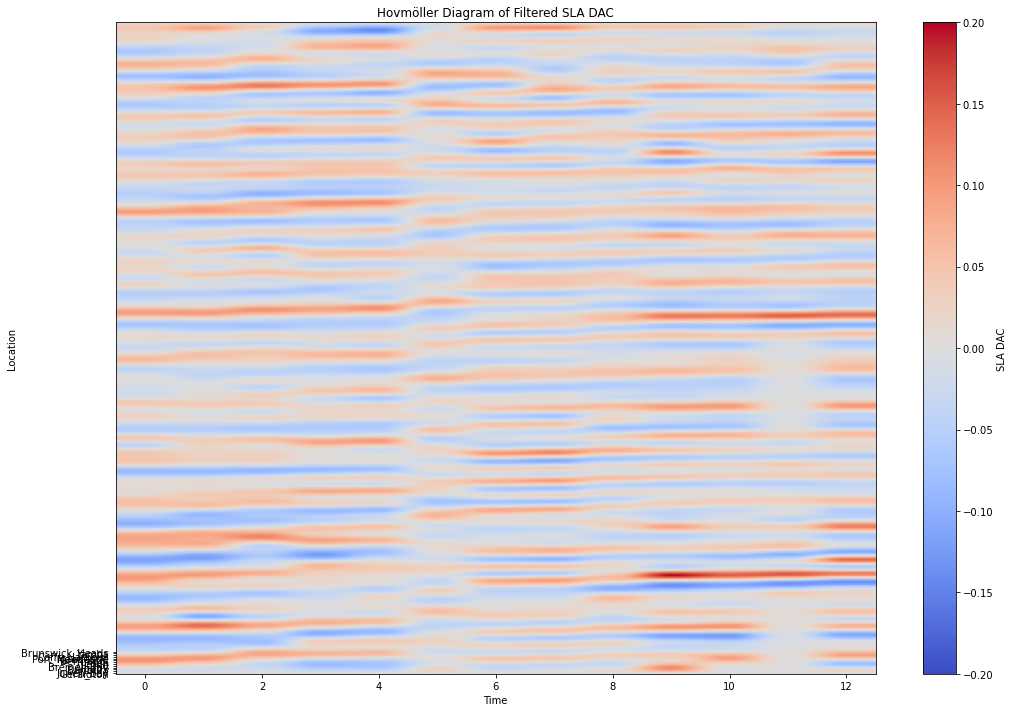

In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
from scipy.signal import butter, filtfilt
from fuzzywuzzy import process

# Load the dataset
file_path = 'gesla_2004_selected_lowess_dac_correctedaustralia_2004.nc'
dataset = xr.open_dataset(file_path)

# Convert hourly data to daily means
daily_dataset = dataset.resample(date_time='D').mean()

# Extract necessary variables
sla_dac = daily_dataset['sla_dac'].values
time = daily_dataset['date_time'].values
site_names = dataset['site_name'].values
latitudes = dataset['latitude'].values
longitudes = dataset['longitude'].values

# Define the Butterworth bandpass filter
def butter_bandpass(lowcut, highcut, fs, order=5):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return b, a

def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = filtfilt(b, a, data, axis=0)
    return y

def interpolate_nan(data):
    """Interpolate NaNs in the data."""
    nans, x = np.isnan(data), lambda z: z.nonzero()[0]
    data[nans] = np.interp(x(nans), x(~nans), data[~nans])
    return data

# Frequency cutoffs in cycles per day
lowcut = 0.035
highcut = 0.15
fs = 1.0  # Sampling frequency in cycles per day

# List of selected locations to keep in the plot
selected_locations = [
    'Geraldton', 'Jurien Bay', 'Hillarys', 'Bunbury', 'Albany', 'Bremer Bay', 'Esperance',
    'Thevenard', 'Portland', 'Lorne', 'Port Welshpool Pier', 'Eden', 'Bermagui', 'Ulladulla',
    'Port Kembla', 'Newcastle', 'Port Macquarie', 'Coffs Harbour', 'Yamba', 'Brunswick Heads'
]

# Find closest matches for selected locations in the dataset's site_names
filtered_indices = []
valid_site_names = []
for loc in selected_locations:
    match = process.extractOne(loc, site_names)
    if match[1] >= 80:  # Minimum similarity score threshold
        filtered_indices.append(np.where(site_names == match[0])[0][0])
        valid_site_names.append(match[0])
    else:
        print(f"No close match found for '{loc}'.")

# Filter sla_dac and reorder according to filtered indices
filtered_sla_dac = sla_dac[:, filtered_indices]

# Apply the Butterworth bandpass filter to each time series
filtered_sla_dac_filtered = []
for i in range(filtered_sla_dac.shape[1]):
    series = filtered_sla_dac[:, i]
    nan_count = np.isnan(series).sum()
    if nan_count <= 0.9 * len(time):  # Keep if less than or equal to 90% NaNs
        if nan_count > 0:
            series = interpolate_nan(series)
        series = butter_bandpass_filter(series, lowcut, highcut, fs, order=5)
        filtered_sla_dac_filtered.append(series)

filtered_sla_dac_filtered = np.array(filtered_sla_dac_filtered)

# Create the Hovmöller diagram using imshow with masked array
fig, ax = plt.subplots(figsize=(15, 10))

# Set normalization for the color scale
norm = Normalize(vmin=-0.2, vmax=0.2)

# Plot using imshow with masked array
im = ax.imshow(filtered_sla_dac_filtered.T, aspect='auto', cmap='coolwarm', origin='lower', norm=norm)

# Set labels and title
ax.set_xlabel('Time')
ax.set_ylabel('Location')
ax.set_title('Hovmöller Diagram of Filtered SLA DAC')

# Add colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('SLA DAC')

# Set y-axis ticks and labels (locations)
ax.set_yticks(np.arange(len(valid_site_names)))
ax.set_yticklabels(valid_site_names)

plt.tight_layout()
plt.show()

